In [1]:
import Pkg; Pkg.activate(@__DIR__); Pkg.add("JLD2"); Pkg.instantiate()

  Activating project at `/workspaces/lecture-notebooks/Lecture 10`
   Resolving package versions...
  No Changes to `/workspaces/lecture-notebooks/Lecture 10/Project.toml`
  No Changes to `/workspaces/lecture-notebooks/Lecture 10/Manifest.toml`


In [2]:
using LinearAlgebra
using PyPlot
using ForwardDiff
using RobotZoo
using RobotDynamics
using JLD2

In [3]:
#Cartpole Dynamics
a = RobotZoo.Cartpole()
h = 0.05

0.05

In [4]:
function dynamics_rk4(x,u)
    #RK4 integration with zero-order hold on u
    f1 = RobotZoo.dynamics(a, x, u)
    f2 = RobotZoo.dynamics(a, x + 0.5*h*f1, u)
    f3 = RobotZoo.dynamics(a, x + 0.5*h*f2, u)
    f4 = RobotZoo.dynamics(a, x + h*f3, u)
    return x + (h/6.0)*(f1 + 2*f2 + 2*f3 + f4)
end

dynamics_rk4 (generic function with 1 method)

In [5]:
function dfdx(x,u)
    ForwardDiff.jacobian(dx->dynamics_rk4(dx,u),x)
end

function dfdu(x,u)
    ForwardDiff.derivative(du->dynamics_rk4(x,du),u)
end

dfdu (generic function with 1 method)

In [6]:
function dAdx(x,u)
    ForwardDiff.jacobian(dx->vec(dfdx(dx,u)'),x)
end

function dBdx(x,u)
    ForwardDiff.jacobian(dx->dfdu(dx,u),x)
end

function dAdu(x,u)
    ForwardDiff.derivative(du->vec(dfdx(x,du)'),u)
end

function dBdu(x,u)
    ForwardDiff.derivative(du->dfdu(x,du),u)
end

dBdu (generic function with 1 method)

In [7]:
Nx = 4     # number of state
Nu = 1     # number of controls
Tfinal = 5.0 # final time
Nt = Int(Tfinal/h)+1    # number of time steps
thist = Array(range(0,h*(Nt-1), step=h));

In [8]:
# Cost weights
Q = Diagonal([1.0*ones(2); 1.0*ones(2)]);
R = 0.1;
Qn = Array(100.0*I(Nx));

In [9]:
function stage_cost(x,u)
    return 0.5*((x-xgoal)'*Q*(x-xgoal)) + 0.5*R*u*u
end

stage_cost (generic function with 1 method)

In [10]:
function terminal_cost(x)
    return 0.5*(x-xgoal)'*Qn*(x-xgoal)
end

terminal_cost (generic function with 1 method)

In [11]:
function cost(xtraj,utraj)
    J = 0.0
    for k = 1:(Nt-1)
        J += stage_cost(xtraj[:,k],utraj[k])
    end
    J += terminal_cost(xtraj[:,Nt])
    return J
end

cost (generic function with 1 method)

In [17]:
function backward_pass!(p,P,d,K)
    
    ΔJ = 0.0
    p[:,Nt] .= Qn*(xtraj[:,Nt]-xgoal)
    P[:,:,Nt] .= Qn
    
    for k = (Nt-1):-1:1
        #Calculate derivatives
        q = Q*(xtraj[:,k]-xgoal)
        r = R*utraj[k]
    
        A = dfdx(xtraj[:,k], utraj[k])
        B = dfdu(xtraj[:,k], utraj[k])
    
        gx = q + A'*p[:,k+1]
        gu = r + B'*p[:,k+1]
    
        #iLQR (Gauss-Newton) version
        # Gxx = Q + A'*P[:,:,k+1]*A
        # Guu = R + B'*P[:,:,k+1]*B
        # Gxu = A'*P[:,:,k+1]*B
        # Gux = B'*P[:,:,k+1]*A
        
        #DDP (full Newton) version
        TAx = dAdx(xtraj[:,k], utraj[k])
        Bx = dBdx(xtraj[:,k], utraj[k])
        TAu = dAdu(xtraj[:,k], utraj[k])
        Bu = dBdu(xtraj[:,k], utraj[k])
        Gxx = Q + A'*P[:,:,k+1]*A + kron(p[:,k+1]',I(Nx))*TAx
        Guu = R + B'*P[:,:,k+1]*B + (kron(p[:,k+1]',I(Nu))*Bu)[1]
        Gxu = A'*P[:,:,k+1]*B + kron(p[:,k+1]',I(Nx))*TAu
        Gux = B'*P[:,:,k+1]*A + kron(p[:,k+1]',I(Nu))*Bx
        
        β = 0.1
        while !isposdef(Symmetric([Gxx Gxu; Gux Guu]))
            Gxx+=A'*β*I*A
            Guu+=B'*I*B
            Gxu+=A'*β*I*B
            Gux+=B'*β*I*A
            β = 2*β
            display("regularizing G")
        #   display(β)
        end
        #DDP over
        d[k] = Guu\gu
        K[:,:,k] .= Guu\Gux
    
        p[:,k] .= dropdims(gx - K[:,:,k]'*gu + K[:,:,k]'*Guu*d[k] - Gxu*d[k], dims=2)
        P[:,:,k] .= Gxx + K[:,:,k]'*Guu*K[:,:,k] - Gxu*K[:,:,k] - K[:,:,k]'*Gux
    
        ΔJ += gu'*d[k]
    end
    
    return ΔJ
end

backward_pass! (generic function with 1 method)

In [14]:
#Initial guess
x0 = [0; 0; 0; 0]
xgoal = [0, pi, 0, 0]
xtraj = kron(ones(1,Nt), x0)
utraj = randn(Nt-1);
# f=jldopen("guess.jld2"，"r")
# utraj =f["utraj"];

100-element Vector{Float64}:
 -0.11003099917129186
 -0.6442024091420222
  1.2922152390813433
  1.1957901879876849
 -0.03200981217267651
 -0.9666983098414805
  0.9487185989390385
  1.3396616242796875
  0.3546480658623826
  1.0938322758114767
  ⋮
 -0.2797281339788255
  0.04692195302598549
  1.1375153815334662
  0.14565476413387016
  0.7872262505716612
  2.1536824225963604
 -1.0437513385310224
  0.16995500839950886
  1.1853899394921406

In [15]:
#Initial Rollout
for k = 1:(Nt-1)
    xtraj[:,k+1] .= dynamics_rk4(xtraj[:,k],utraj[k])
end
J = cost(xtraj,utraj)

1051.6906425801608

In [ ]:
#DDP Algorithm
using Printf
p = ones(Nx,Nt)
P = zeros(Nx,Nx,Nt)
d = ones(Nt-1)
K = zeros(Nu,Nx,Nt-1)
ΔJ = 0.0

xn = zeros(Nx,Nt)
un = zeros(Nt-1)

gx = zeros(Nx)
gu = 0.0
Gxx = zeros(Nx,Nx)
Guu = 0.0
Gxu = zeros(Nx)
Gux = zeros(Nx)

iter = 0
while maximum(abs.(d[:])) >  1e-3
    iter += 1    
    
    #Backward Pass
    ΔJ = backward_pass!(p,P,d,K)

    #Forward rollout with line search
    xn[:,1] = xtraj[:,1]
    α = 1.0
    for k = 1:(Nt-1)
        un[k] = utraj[k] - α*d[k] - dot(K[:,:,k],xn[:,k]-xtraj[:,k])
        xn[:,k+1] .= dynamics_rk4(xn[:,k],un[k])
    end
    Jn = cost(xn,un)
    
    while isnan(Jn) || Jn > (J - 1e-2*α*ΔJ)
        α = 0.5*α
        for k = 1:(Nt-1)
            un[k] = utraj[k] - α*d[k] - dot(K[:,:,k],xn[:,k]-xtraj[:,k])
            xn[:,k+1] .= dynamics_rk4(xn[:,k],un[k])
        end
        Jn = cost(xn,un)
    end

    # logging
    if rem(iter - 1, 100) == 0
        @printf "iter     J           ΔJ        |d|         α       \n"
        @printf "---------------------------------------------------\n"
    end
    if rem(iter - 1, 10) == 0 
        @printf("%3d   %10.3e  %9.2e  %9.2e  %6.4f  \n",
              iter, J, ΔJ, maximum(abs.(d[:])), α)
    end
    
    J = Jn
    xtraj .= xn
    utraj .= un
end

In [19]:
iter

1

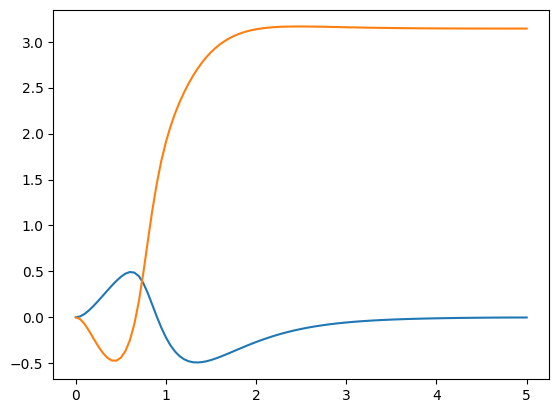

In [22]:
clf()
plot(thist,xtraj[1,:])
plot(thist,xtraj[2,:])
display(gcf())

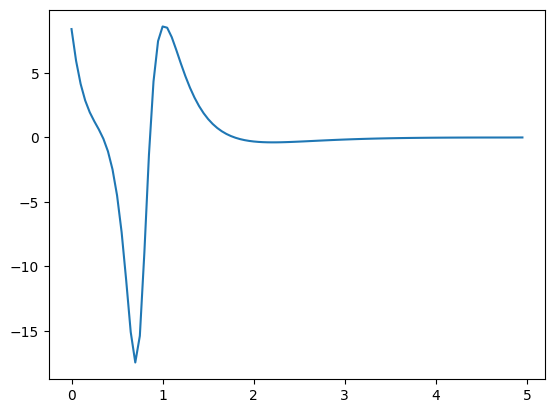

In [23]:
clf()
plot(thist[1:Nt-1],utraj)
display(gcf())

In [19]:
import MeshCat as mc 

function rotx(θ)
    s, c = sincos(θ)
    return [1 0 0; 0 c -s; 0 s c]
end
function create_cartpole!(vis)
    mc.setobject!(vis[:cart], mc.HyperRectangle(mc.Vec(-.25,-1.0,-.15), mc.Vec(0.5,2,0.3)))
    mc.setobject!(vis[:pole], mc.Cylinder(mc.Point(0,0,-.75), mc.Point(0,0,.75), 0.05))
    mc.setobject!(vis[:a], mc.HyperSphere(mc.Point(0,0,0.0),0.1))
    mc.setobject!(vis[:b], mc.HyperSphere(mc.Point(0,0,0.0),0.1))
end
function update_cartpole_transform!(vis,x)
    pole_o = 0.3
    px = x[1]
    θ = x[2]
    mc.settransform!(vis[:cart], mc.Translation([0,px,0.0]))
    p1 = [pole_o,px,0]
    p2 = p1 + 1.5*[0,sin(θ), -cos(θ)]
    mc.settransform!(vis[:a], mc.Translation(p1))
    mc.settransform!(vis[:b], mc.Translation(p2))
    mc.settransform!(vis[:pole], mc.Translation(0.5*(p1 + p2)) ∘ mc.LinearMap(rotx(θ))) 
end

function animate_cartpole(X, dt)
    vis = mc.Visualizer()
    create_cartpole!(vis)
    anim = mc.Animation(vis; fps=floor(Int,1/dt))
    for k = 1:length(X)
        mc.atframe(anim, k) do
            update_cartpole_transform!(vis,X[k])
        end
    end
    mc.setanimation!(vis, anim)
    return mc.render(vis)
end

animate_cartpole (generic function with 1 method)

In [20]:
X1 = [Vector(x) for x in eachcol(xtraj)];
animate_cartpole(X1, h)

┌ Info: Listening on: 127.0.0.1:8700, thread id: 1
└ @ HTTP.Servers /home/codespace/.julia/packages/HTTP/4AUPl/src/Servers.jl:382
┌ Info: MeshCat server started. You can open the visualizer by visiting the following URL in your browser:
│ http://127.0.0.1:8700
└ @ MeshCat /home/codespace/.julia/packages/MeshCat/9QrxD/src/visualizer.jl:43


MeshCat.DisplayedVisualizer(MeshCat.CoreVisualizer(MeshCat.SceneTrees.SceneNode(nothing, nothing, Dict{String, Vector{UInt8}}(), UInt8[0x83, 0xa7, 0x6f, 0x70, 0x74, 0x69, 0x6f, 0x6e, 0x73, 0x82  …  0x5f, 0x61, 0x6e, 0x69, 0x6d, 0x61, 0x74, 0x69, 0x6f, 0x6e], Dict{String, MeshCat.SceneTrees.SceneNode}("meshcat" => MeshCat.SceneTrees.SceneNode(nothing, nothing, Dict{String, Vector{UInt8}}(), nothing, Dict{String, MeshCat.SceneTrees.SceneNode}("pole" => MeshCat.SceneTrees.SceneNode(UInt8[0x83, 0xa6, 0x6f, 0x62, 0x6a, 0x65, 0x63, 0x74, 0x84, 0xaa  …  0x73, 0x68, 0x63, 0x61, 0x74, 0x2f, 0x70, 0x6f, 0x6c, 0x65], nothing, Dict{String, Vector{UInt8}}(), nothing, Dict{String, MeshCat.SceneTrees.SceneNode}()), "b" => MeshCat.SceneTrees.SceneNode(UInt8[0x83, 0xa6, 0x6f, 0x62, 0x6a, 0x65, 0x63, 0x74, 0x84, 0xaa  …  0x2f, 0x6d, 0x65, 0x73, 0x68, 0x63, 0x61, 0x74, 0x2f, 0x62], nothing, Dict{String, Vector{UInt8}}(), nothing, Dict{String, MeshCat.SceneTrees.SceneNode}()), "cart" => MeshCat.SceneTrees.SceneNode(UInt8[0x83, 0xa6, 0x6f, 0x62, 0x6a, 0x65, 0x63, 0x74, 0x84, 0xaa  …  0x73, 0x68, 0x63, 0x61, 0x74, 0x2f, 0x63, 0x61, 0x72, 0x74], nothing, Dict{String, Vector{UInt8}}(), nothing, Dict{String, MeshCat.SceneTrees.SceneNode}()), "a" => MeshCat.SceneTrees.SceneNode(UInt8[0x83, 0xa6, 0x6f, 0x62, 0x6a, 0x65, 0x63, 0x74, 0x84, 0xaa  …  0x2f, 0x6d, 0x65, 0x73, 0x68, 0x63, 0x61, 0x74, 0x2f, 0x61], nothing, Dict{String, Vector{UInt8}}(), nothing, Dict{String, MeshCat.SceneTrees.SceneNode}()))))), Set{HTTP.WebSockets.WebSocket}(), ip"127.0.0.1", 8700, HTTP.Servers.Server{HTTP.Servers.Listener{Nothing, Sockets.TCPServer}}(HTTP.Servers.Listener{Nothing, Sockets.TCPServer}(Sockets.InetAddr{Sockets.IPv4}(ip"127.0.0.1", 8700), "127.0.0.1", "8700", nothing, Sockets.TCPServer(RawFD(24) active)), nothing, Set{HTTP.Connections.Connection}(), Task (runnable) @0x00007101af058c90, ReentrantLock(nothing, 0x00000000, 0x00, Base.GenericCondition{Base.Threads.SpinLock}(Base.IntrusiveLinkedList{Task}(nothing, nothing), Base.Threads.SpinLock(0)), (0, 124250496931376, 1))), MeshCat.AnimationContext[]))